# 01d — Bases de Datos Vectoriales

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01d-vectordb.ipynb)

> Este tema forma parte del **Bloque 1 — Fundamentos**. Se recomienda
> haber visto [01c-embeddings.qmd](01c-embeddings.qmd) primero.

> Este tema representa el paso histórico de aprender un espacio
> semántico a operar sobre él. El [panorama histórico](00-panorama.qmd)
> presenta la evolución conceptual; aquí estudiamos la indexación y la
> búsqueda necesarias para utilizar embeddings en sistemas reales.

In [1]:
!pip install -q chromadb faiss-cpu sentence-transformers matplotlib


In [2]:
import os

# Workaround para conflicto de OpenMP en macOS ARM64 (PyTorch + sklearn + FAISS
# cargan múltiples libomp.dylib que entran en conflicto durante clustering,
# causando SIGSEGV). Ver ~/Library/Logs/DiagnosticReports/Python-*.ips
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.

## Bases de Datos Vectoriales

Una vez que tenemos embeddings, necesitamos almacenarlos y buscarlos
eficientemente. Aquí entran las **bases de datos vectoriales**.

> **Idioma de los ejemplos**
>
> Los modelos de embeddings que usamos (`all-MiniLM-L6-v2`) están
> entrenados en inglés, por lo que los ejemplos usan texto en inglés.
> Usar un tokenizador inglés sobre texto español produce más subtokens
> por palabra y embeddings de menor calidad. Para trabajar con español,
> cambia a un modelo multilingüe como `intfloat/multilingual-e5-small`.

### Búsqueda exacta (KNN) vs. aproximada (ANN)

<figure id="fig-knn-vs-ann">
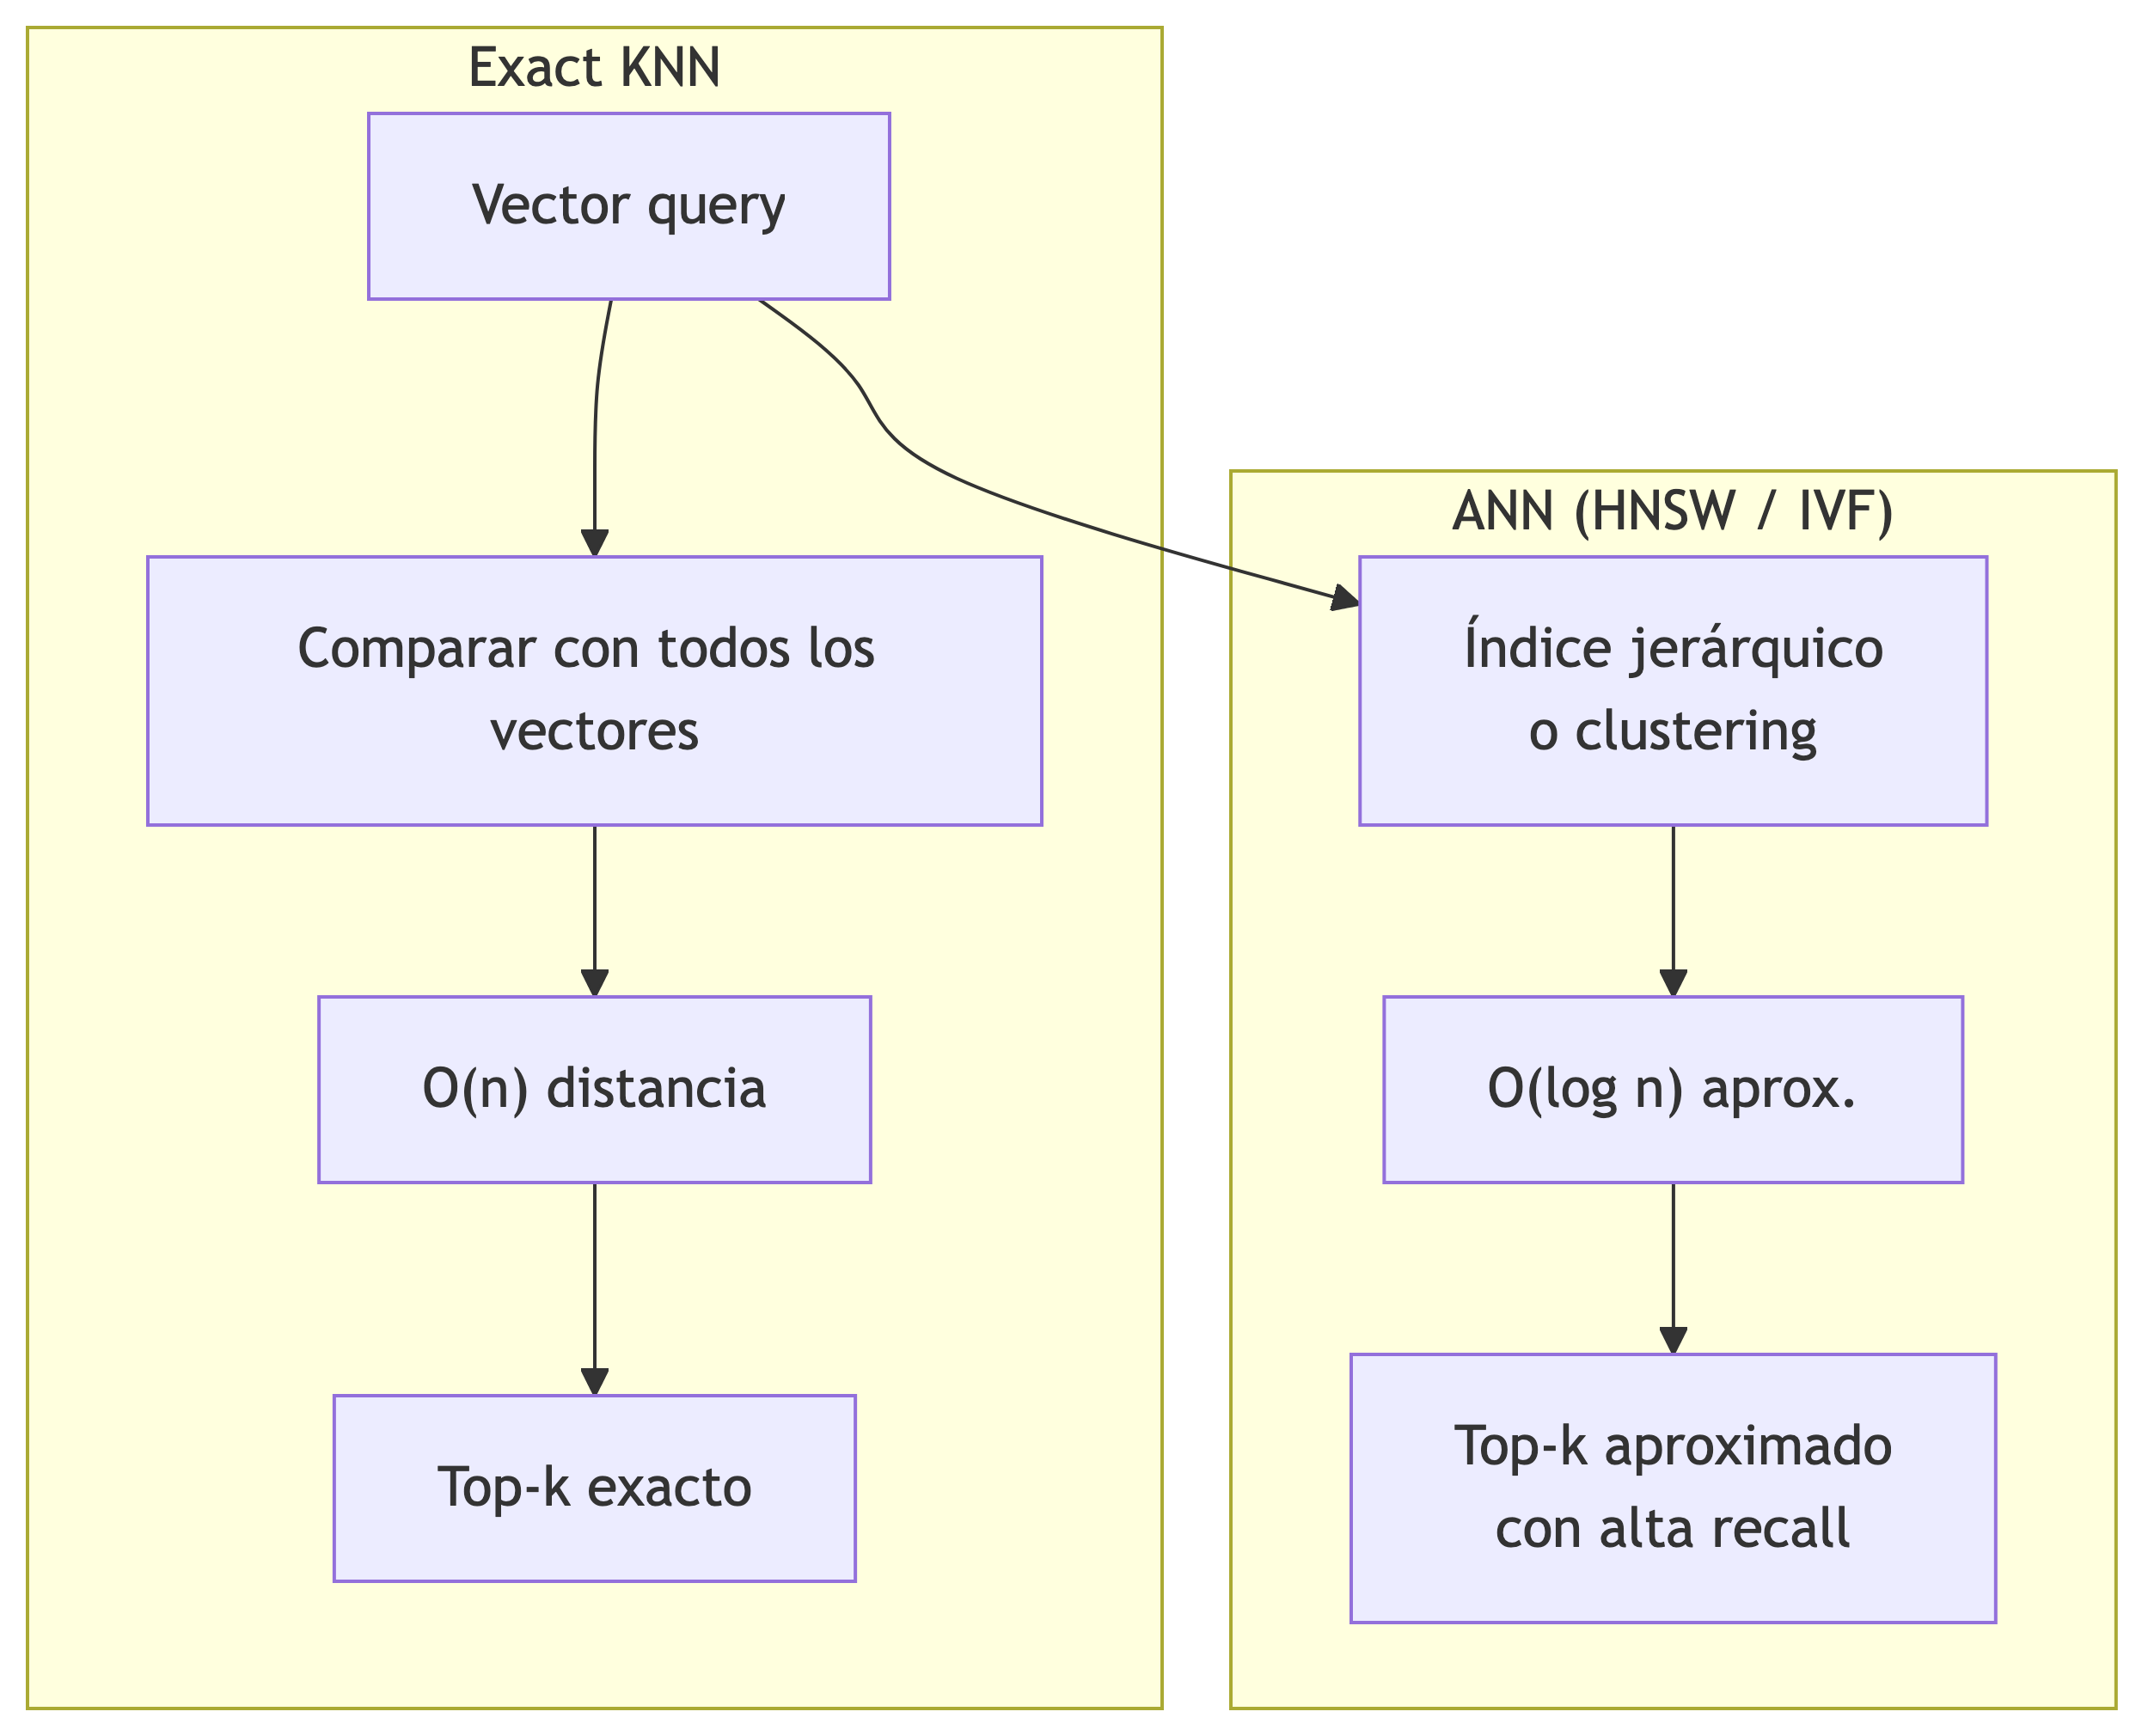
<figcaption>Figure 1</figcaption>
</figure>

| Método     | Precisión | Velocidad | Memoria |
|------------|-----------|-----------|---------|
| KNN exacto | 100 %     | O(n)      | —       |
| HNSW       | 99 %+     | O(log n)  | Alta    |
| IVF        | 95-99 %   | O(√n)     | Media   |

Table 1: Comparativa de métodos de búsqueda exacta vs. aproximada

### HNSW (Hierarchical Navigable Small World)

El algoritmo más popular en producción (usado por Chroma, Qdrant,
Pinecone). Construye un grafo multi-capa donde:

- Las capas superiores tienen pocos nodos (conexiones largas)
- Las capas inferiores tienen todos los nodos (conexiones cortas)
- La búsqueda comienza en la capa superior y desciende, recorriendo el
  grafo greedy

<figure id="fig-hnsw-grafo">
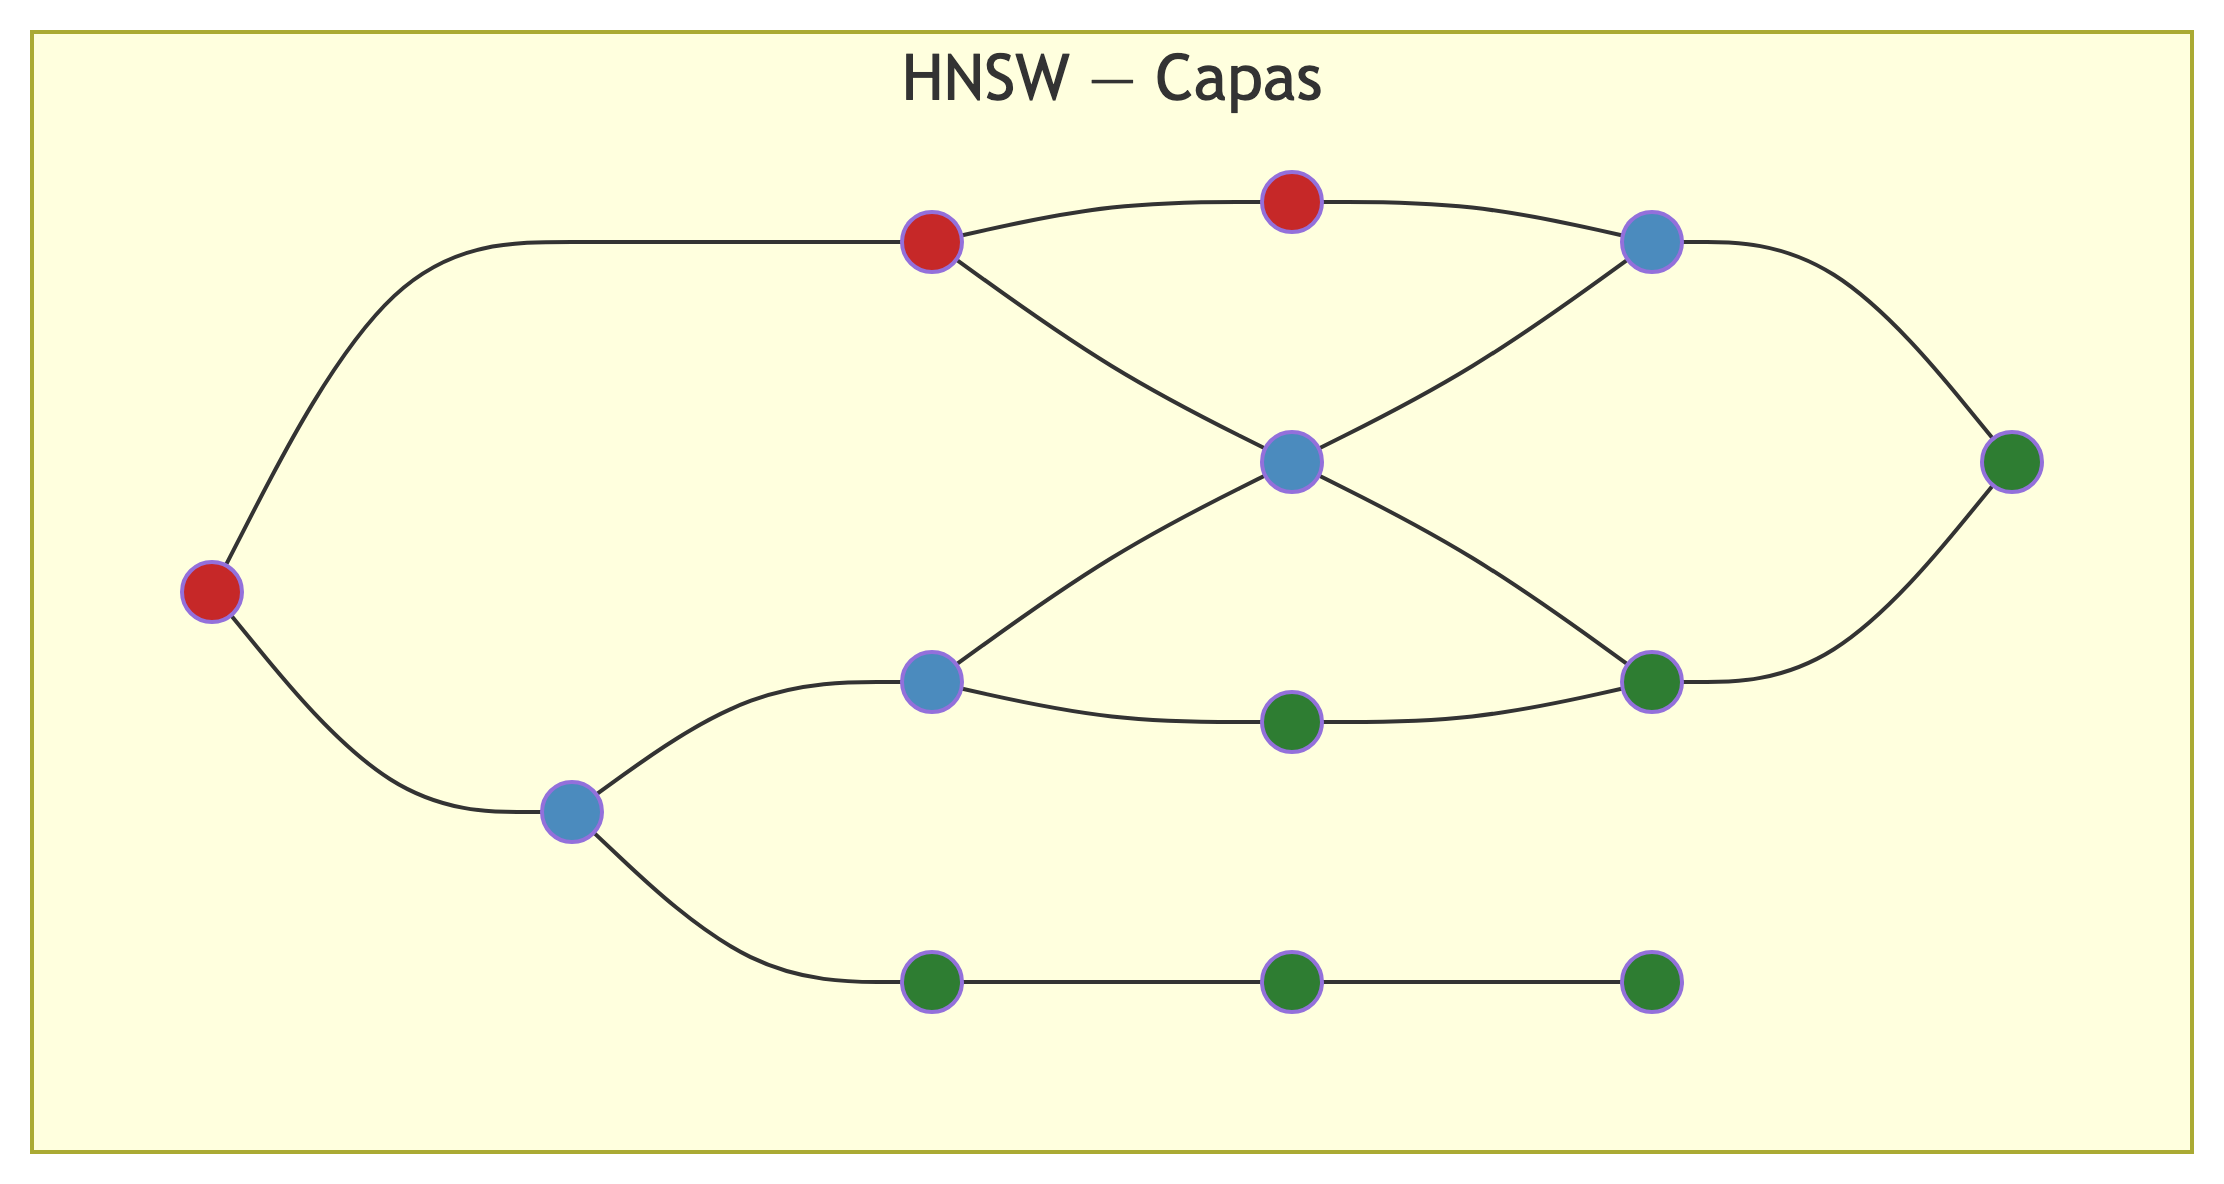
<figcaption>Figure 2</figcaption>
</figure>

### Métricas de similitud

| Métrica | Fórmula | Cuándo usarla |
|------------------------|------------------------|------------------------|
| **Coseno** | cos(, ) = | Embeddings normalizados (recomendada) |
| **Producto escalar** |  | Embeddings normalizados (equivalente al coseno) |
| **L2 (Euclídea)** | \| - \|\_2 | Embeddings no normalizados, búsqueda por cercanía absoluta |

Table 2: Métricas de distancia y similitud entre vectores

> **Regla práctica**
>
> Siempre **normaliza los embeddings** (\|\|v\|\| = 1). Con embeddings
> normalizados, coseno y producto escalar son equivalentes, y la
> búsqueda es más estable.

In [3]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euclidean_dist(a, b):
    return np.linalg.norm(a - b)

a = np.array([1.0, 0.0, 0.0])
b = np.array([0.8, 0.6, 0.0])
c = np.array([0.0, 1.0, 0.0])

print(f"coseno(a, b): {cosine_sim(a, b):.3f}")
print(f"coseno(a, c): {cosine_sim(a, c):.3f}")
print(f"coseno(b, c): {cosine_sim(b, c):.3f}")
print()
print(f"L2(a, b): {euclidean_dist(a, b):.3f}")
print(f"L2(a, c): {euclidean_dist(a, c):.3f}")
print(f"L2(b, c): {euclidean_dist(b, c):.3f}")


coseno(a, b): 0.800
coseno(a, c): 0.000
coseno(b, c): 0.600

L2(a, b): 0.632
L2(a, c): 1.414
L2(b, c): 0.894

### Chroma — Base de datos vectorial local

Chroma es una base de datos vectorial embebida que funciona en local sin
servidor. Ideal para prototipado y proyectos pequeños/medios.

In [4]:
import chromadb
from chromadb.config import Settings

# Cliente persistente (los datos se guardan en disco)
client = chromadb.Client(Settings(
    persist_directory=".chroma_db",
    anonymized_telemetry=False
))

# Crear o recuperar colección
collection = client.get_or_create_collection(
    name="ejemplo_embeddings",
    metadata={"hnsw:space": "cosine"}
)

print(f"Colección '{collection.name}' lista.")
print(f"Total de documentos hasta ahora: {collection.count()}")


Colección 'ejemplo_embeddings' lista.
Total de documentos hasta ahora: 0

In [5]:
# Cargar modelo de embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")

# Añadir documentos con sus embeddings
documentos = [
    "Artificial intelligence is revolutionizing medicine",
    "Transformers can process sequences in parallel",
    "Vector databases optimize semantic search",
    "Fine-tuning with LoRA reduces training cost",
    "Supervised machine learning requires labeled data"
]

ids = [f"doc_{i}" for i in range(len(documentos))]
embeddings_docs = model.encode(documentos).tolist()

collection.add(
    ids=ids,
    documents=documentos,
    embeddings=embeddings_docs
)

print(f"Documentos insertados: {collection.count()}")


Documentos insertados: 5

In [6]:
# Búsqueda semántica
query = "How do current models process sequences?"
query_embedding = model.encode([query]).tolist()

resultados = collection.query(
    query_embeddings=query_embedding,
    n_results=3
)

print(f"Consulta: {query}\n")
for i, (doc, dist) in enumerate(zip(resultados["documents"][0], resultados["distances"][0])):
    sim = 1 - dist
    print(f"{i+1}. [sim={sim:.4f}] {doc}")


Consulta: How do current models process sequences?

1. [sim=0.4474] Transformers can process sequences in parallel
2. [sim=0.0992] Supervised machine learning requires labeled data
3. [sim=0.0843] Vector databases optimize semantic search

### FAISS — Indexación en memoria

FAISS (Facebook AI Similarity Search) es una librería de indexación ANN
embebible, ideal para integración en pipelines de Python sin necesidad
de un servidor de base de datos.

In [7]:
import faiss

# Convertir embeddings a matriz numpy
emb_matrix = np.array(embeddings_docs).astype("float32")
dimension = emb_matrix.shape[1]

# Índice plano (exacto) - solo para comparación
index_exact = faiss.IndexFlatL2(dimension)
index_exact.add(emb_matrix)

# Índice IVF con cuantización (aproximado)
nlist = 2  # número de clusters
quantizer = faiss.IndexFlatL2(dimension)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)
index_ivf.train(emb_matrix)
index_ivf.add(emb_matrix)
index_ivf.nprobe = 2  # número de clusters a explorar

# Búsqueda en ambos índices
query_vec = np.array(query_embedding).astype("float32")
dist_exact, idx_exact = index_exact.search(query_vec, 3)
dist_ivf, idx_ivf = index_ivf.search(query_vec, 3)

print("FAISS — Comparación exacto vs. aproximado:\n")
print("Índice exacto (FlatL2):")
for i, idx in enumerate(idx_exact[0]):
    print(f"  {i+1}. {documentos[idx]} (dist: {dist_exact[0][i]:.4f})")

print("\nÍndice aproximado (IVF):")
for i, idx in enumerate(idx_ivf[0]):
    print(f"  {i+1}. {documentos[idx]} (dist: {dist_ivf[0][i]:.4f})")

print(f"\n¿Mismos resultados? {set(idx_exact[0]) == set(idx_ivf[0])}")


FAISS — Comparación exacto vs. aproximado:

Índice exacto (FlatL2):
  1. Transformers can process sequences in parallel (dist: 1.1052)
  2. Supervised machine learning requires labeled data (dist: 1.8015)
  3. Vector databases optimize semantic search (dist: 1.8313)

Índice aproximado (IVF):
  1. Transformers can process sequences in parallel (dist: 1.1052)
  2. Supervised machine learning requires labeled data (dist: 1.8015)
  3. Vector databases optimize semantic search (dist: 1.8313)

¿Mismos resultados? True

WARNING clustering 5 points to 2 centroids: please provide at least 78 training points

### Comparativa operacional

| Característica | Chroma | FAISS | Qdrant | Pinecone |
|---------------|---------------|---------------|---------------|---------------|
| **Tipo** | Base de datos | Librería | Base de datos | SaaS |
| **Infraestructura** | Local (sin servidor) | Embebible | Servidor Docker | Cloud |
| **Persistencia** | Disco (SQLite + vectores) | Memoria / disco | Disco | Cloud |
| **Privacidad** | Total (local) | Total (local) | Según deploy | Datos en cloud |
| **Escala** | \< 1M vectores | \> 1M vectores | 1M+ vectores | Ilimitado |
| **Coste** | Gratuito | Gratuito | Self-hosted gratis | Por uso |
| **API** | Python nativa | Python/C++ | REST + gRPC | REST |

Table 3: Comparativa operacional entre Chroma, FAISS, Qdrant y Pinecone

### Árbol de decisión para elegir

<figure id="fig-arbol-decision-vdb">
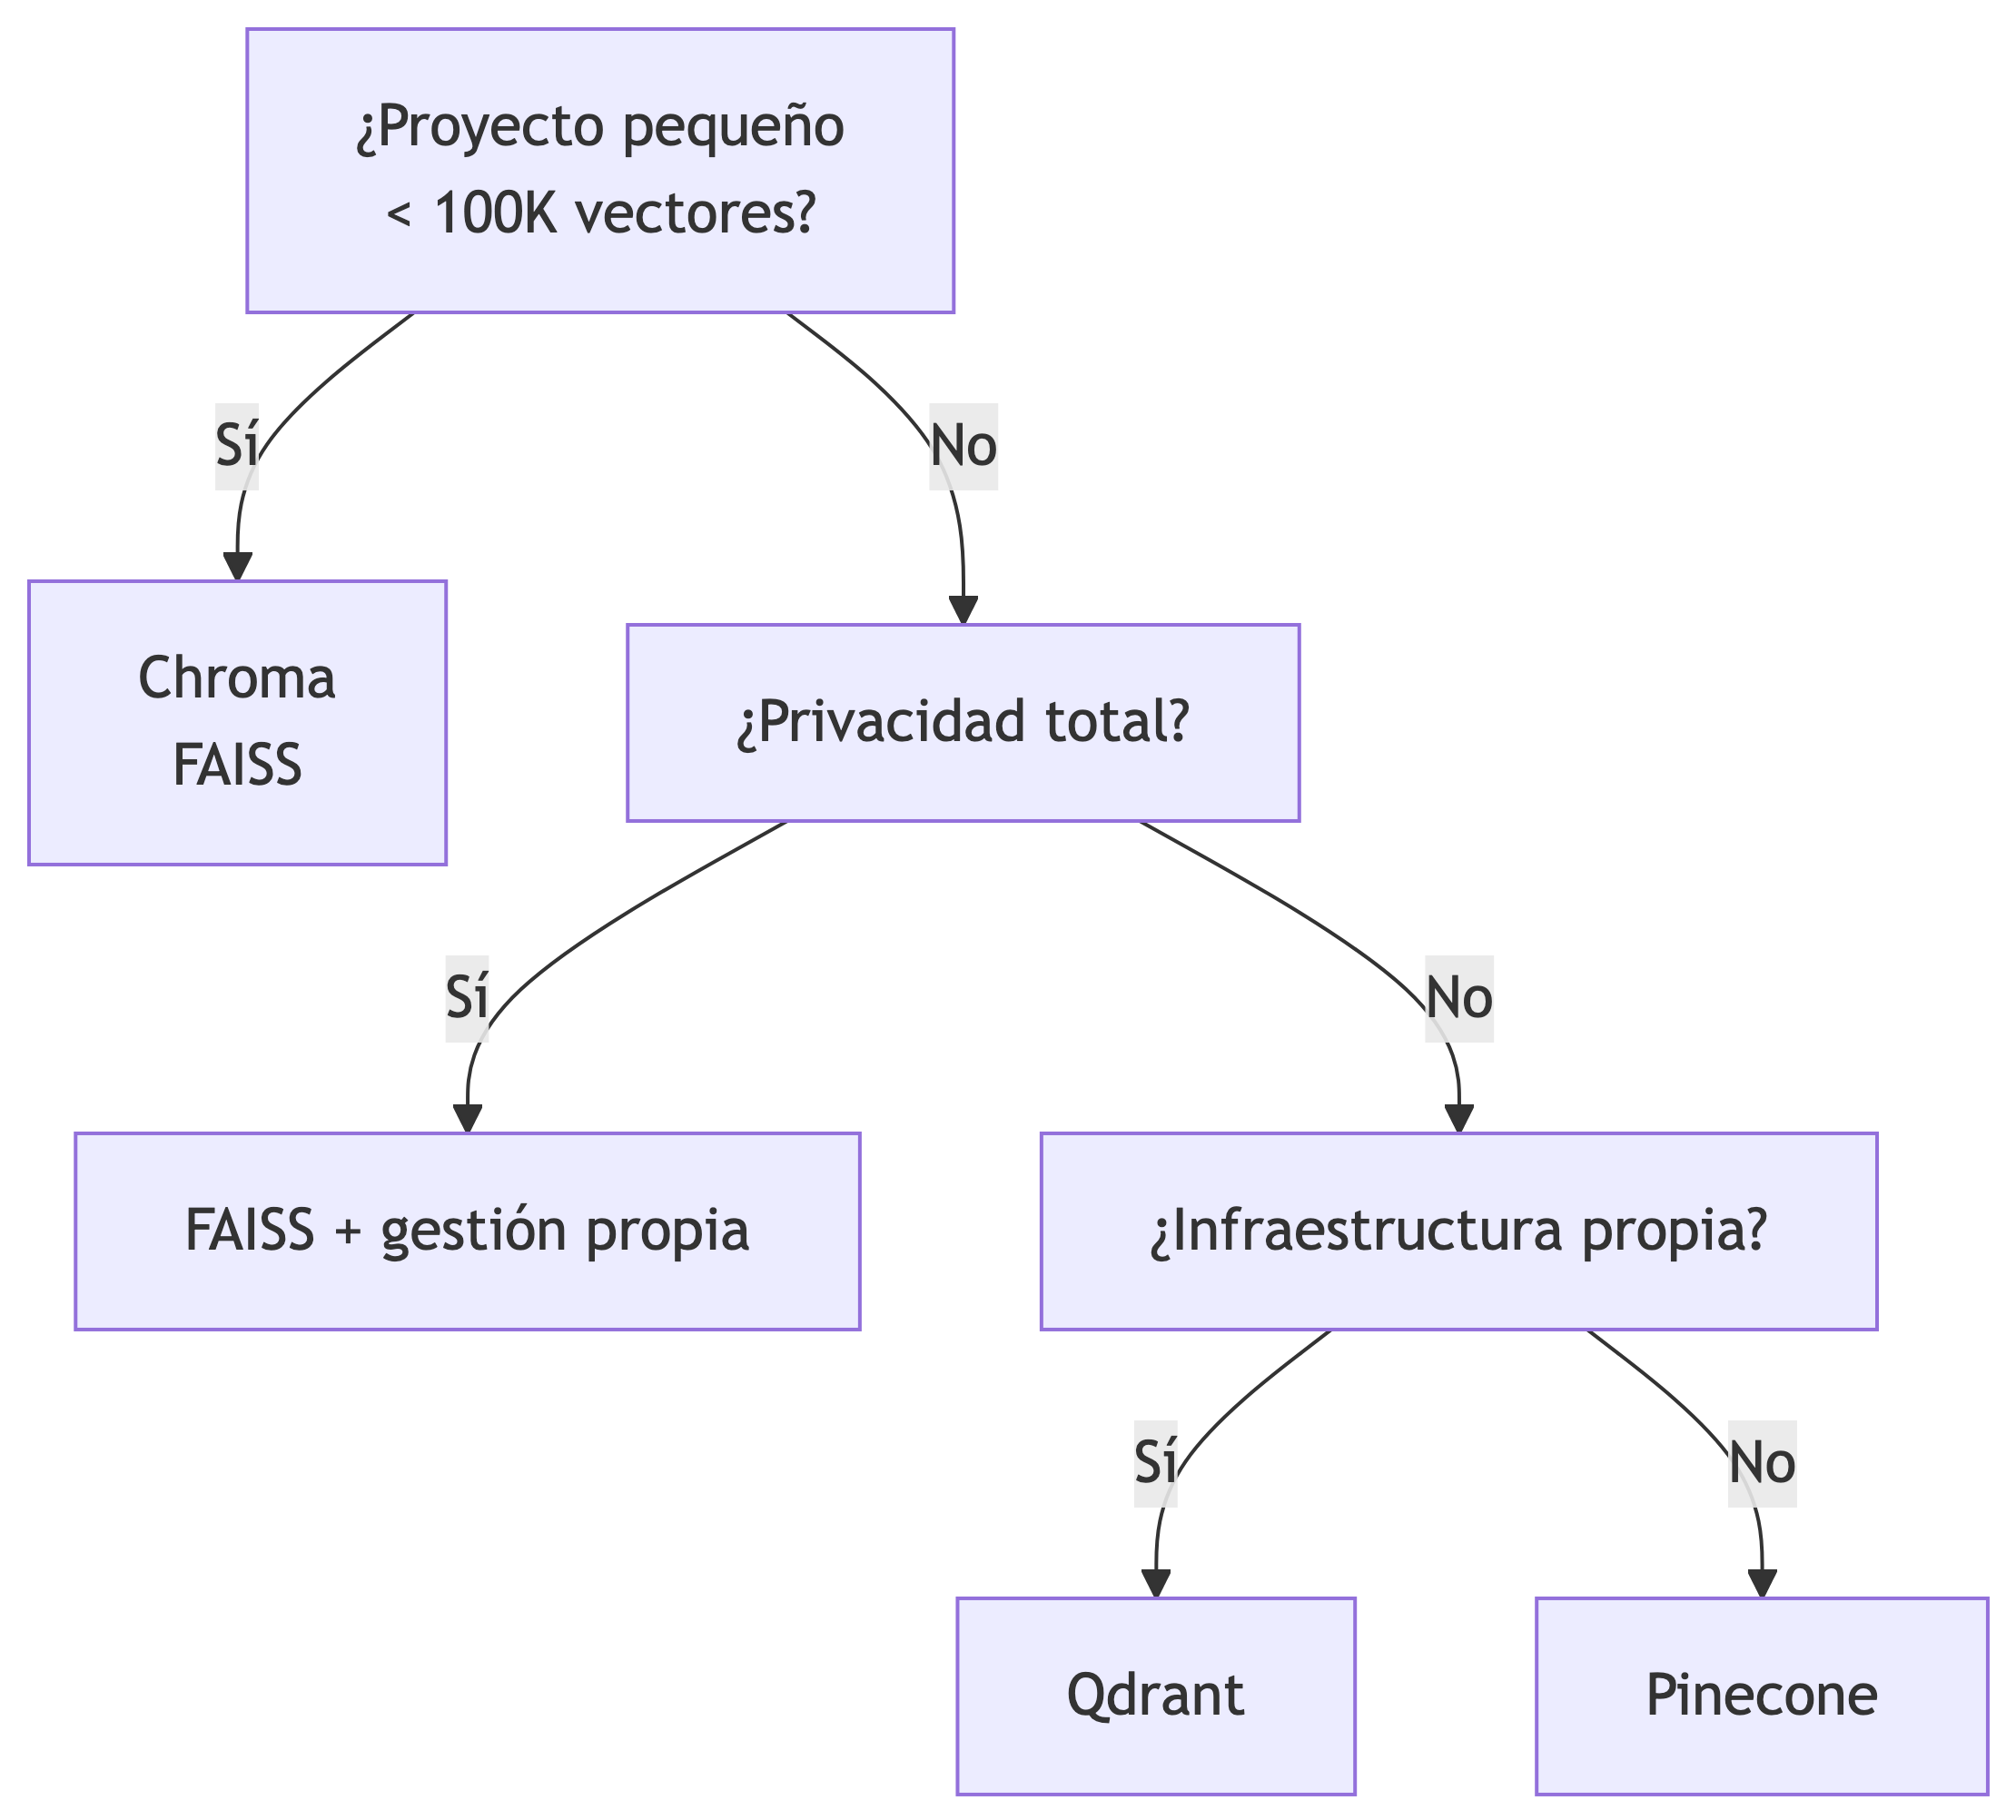
<figcaption>Figure 3</figcaption>
</figure>

> **Consejo práctico**
>
> Para el **proyecto del módulo** empieza con **Chroma**: es local, no
> requiere servidor, y escala bien para el alcance del curso. Si luego
> necesitas más rendimiento, migrar a FAISS o Qdrant es directo porque
> la API de búsqueda semántica es equivalente.

------------------------------------------------------------------------

> Has completado la teoría del **Bloque 1**. Ahora pasa al taller
> práctico: **[HPD 1 — Pipeline de embeddings y búsqueda
> semántica](hpd1-embeddings.qmd)**.

# References